In [1]:
import multirex as mrex
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys 
import pandas as pd
from tqdm import tqdm
import warnings
from sklearn.exceptions import DataConversionWarning
import gc

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import  ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

def remove_warnings():
    warnings.filterwarnings("ignore", category=DeprecationWarning)
    warnings.filterwarnings(action='ignore', category=DataConversionWarning)    

waves=np.loadtxt("waves.txt")
n_points = len(waves)

Numba not installed, using numpy instead
Loading MultiREx version 0.3.2


## Load spectra


In [2]:
import os
import re
import numpy as np
import pandas as pd

def apply_contaminations_from_files(contamination_files, df, n_points):
    """
    Applies multiple contaminations to the data from a list of contamination files
    and returns a DataFrame with all combinations, including the non-contaminated case.

    Parameters:
        contamination_files (list of str): Paths to .txt files containing contaminations.
        df (pandas.DataFrame): Original DataFrame to apply contaminations.
        n_points (int): Number of columns to which the contamination will be applied.

    Returns:
        pandas.DataFrame: DataFrame with all combinations of contaminations, including the
        non-contaminated case, with additional columns 'f_spot' and 'f_fac'.
    """
    df_list = []

    # Non-contaminated case: create a copy and add f_spot and f_fac as 0.0
    df_no_contam = df.copy()
    df_no_contam["f_spot"] = 0.0
    df_no_contam["f_fac"] = 0.0
    # Reorder columns to place 'f_spot' and 'f_fac' at the beginning
    cols = ["f_spot", "f_fac"] + [col for col in df_no_contam.columns if col not in ["f_spot", "f_fac"]]
    df_no_contam = df_no_contam[cols]
    df_list.append(df_no_contam)

    # Regular expression to extract f_spot and f_fac from the file name.
    # Expected pattern: fspot<value>_ffac<value>.txt
    pattern = r"fspot(?P<f_spot>[0-9.]+)_ffac(?P<f_fac>[0-9.]+)\.txt$"

    for file_path in contamination_files:
        # Verify that the file exists
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"The file {file_path} does not exist.")

        # Extract the file name and use the regex pattern to get f_spot and f_fac values
        filename = os.path.basename(file_path)
        match = re.search(pattern, filename)
        if not match:
            raise ValueError(f"The file name '{filename}' does not match the expected pattern.")

        f_spot = float(match.group("f_spot"))
        f_fac = float(match.group("f_fac"))

        # Read contamination data from the file, ensuring it has at least 2 dimensions
        try:
            contamination_data = np.loadtxt(file_path, ndmin=2)
            # If there are at least two columns, take the second one; otherwise, flatten the array
            if contamination_data.shape[1] >= 2:
                contam_values = contamination_data[:, 1]
            else:
                contam_values = contamination_data.flatten()
            # Check that the number of contamination values matches the expected n_points
            if len(contam_values) != n_points:
                raise ValueError(
                    f"The number of contamination values in '{filename}' ({len(contam_values)}) "
                    f"does not match n_points ({n_points})."
                )
        except Exception as e:
            raise ValueError(f"Error reading the file {file_path}: {e}")

        # Reverse the contamination values if needed (e.g., to match column order)
        contam_values = contam_values[::-1]

        # Create a copy of the original DataFrame for contamination application
        df_contam = df.copy()
        # Multiply the last n_points columns by the contamination values
        data_columns = df_contam.columns[-n_points:]
        df_contam[data_columns] = df_contam[data_columns].multiply(contam_values, axis=1)

        # Add the contamination parameters as new columns
        df_contam["f_spot"] = f_spot
        df_contam["f_fac"] = f_fac
        # Reorder columns to place the new parameters at the beginning
        cols = ["f_spot", "f_fac"] + [col for col in df_contam.columns if col not in ["f_spot", "f_fac"]]
        df_contam = df_contam[cols]
        df_list.append(df_contam)

    # Concatenate all DataFrames into one final DataFrame
    df_final = pd.concat(df_list, ignore_index=True)
    # Define .data and .params attributes for later use
    df_final.data = df_final.iloc[:, -n_points:]
    df_final.params = df_final.iloc[:, :-n_points]

    return df_final

In [3]:
import pandas as pd

contamination_files = [
    'stellar_contamination/TRAPPIST-1_contam_fspot0.01_ffac0.08.txt',
    'stellar_contamination/TRAPPIST-1_contam_fspot0.01_ffac0.54.txt',
    'stellar_contamination/TRAPPIST-1_contam_fspot0.01_ffac0.70.txt',
    'stellar_contamination/TRAPPIST-1_contam_fspot0.08_ffac0.08.txt',
    'stellar_contamination/TRAPPIST-1_contam_fspot0.08_ffac0.54.txt',
    'stellar_contamination/TRAPPIST-1_contam_fspot0.08_ffac0.70.txt',
    'stellar_contamination/TRAPPIST-1_contam_fspot0.26_ffac0.08.txt',
    'stellar_contamination/TRAPPIST-1_contam_fspot0.26_ffac0.54.txt',
    'stellar_contamination/TRAPPIST-1_contam_fspot0.26_ffac0.70.txt'
]


remove_warnings()

def filtrar_filas(df):
    """
    Filtra las filas de un DataFrame donde al menos una de las columnas
    "atm CH4", "atm O3" o "atm H2O" tenga un valor mayor o igual a -8.

    Si ninguna de estas columnas está presente, devuelve el DataFrame sin cambios.
    """
    columnas_a_filtrar = ["atm CH4", "atm O3", "atm H2O"]
    columnas_presentes = [col for col in columnas_a_filtrar if col in df.columns]

    for chem in columnas_presentes:

        df = df[df[chem]>=-8]
        df.data = df.iloc[:, -n_points:]
        df.params = df.iloc[:, :-n_points]

    return df
try:
    airless_data = pd.read_csv("spec_data/airless_data.csv")
    airless_data = apply_contaminations_from_files(contamination_files, airless_data, n_points)
except Exception as e:
    print(f"Error al procesar airless_data: {e}")

try:
    CO2_data = pd.read_csv("spec_data/CO2_data.csv")
    CO2_data = apply_contaminations_from_files(contamination_files, CO2_data, n_points)
except Exception as e:
    print(f"Error al procesar CO2_data: {e}")

try:
    CH4_data = pd.read_csv("spec_data/CH4_data.csv")
    CH4_data = filtrar_filas(CH4_data)
    CH4_data = apply_contaminations_from_files(contamination_files, CH4_data, n_points)

except Exception as e:
    print(f"Error al procesar CH4_data: {e}")

try:
    O3_data = pd.read_csv("spec_data/O3_data.csv")
    O3_data = filtrar_filas(O3_data)
    O3_data = apply_contaminations_from_files(contamination_files, O3_data, n_points)

except Exception as e:
    print(f"Error al procesar O3_data: {e}")

try:
    H2O_data = pd.read_csv("spec_data/H2O_data.csv")
    H2O_data = filtrar_filas(H2O_data)
    H2O_data = apply_contaminations_from_files(contamination_files, H2O_data, n_points)

except Exception as e:
    print(f"Error al procesar H2O_data: {e}")

try:
    CH4_O3_data = pd.read_csv("spec_data/CH4_O3_data.csv")
    CH4_O3_data = filtrar_filas(CH4_O3_data)
    CH4_O3_data = apply_contaminations_from_files(contamination_files, CH4_O3_data, n_points)

except Exception as e:
    print(f"Error al procesar CH4_O3_data: {e}")

try:
    CH4_H2O_data = pd.read_csv("spec_data/CH4_H2O_data.csv")
    CH4_H2O_data = filtrar_filas(CH4_H2O_data)
    CH4_H2O_data = apply_contaminations_from_files(contamination_files, CH4_H2O_data, n_points)

except Exception as e:
    print(f"Error al procesar CH4_H2O_data: {e}")

try:
    O3_H2O_data = pd.read_csv("spec_data/O3_H2O_data.csv")
    O3_H2O_data = filtrar_filas(O3_H2O_data)
    O3_H2O_data = apply_contaminations_from_files(contamination_files, O3_H2O_data, n_points)

except Exception as e:
    print(f"Error al procesar O3_H2O_data: {e}")

try:
    CH4_O3_H2O_data = pd.read_csv("spec_data/CH4_O3_H2O_data.csv")
    CH4_O3_H2O_data = filtrar_filas(CH4_O3_H2O_data)
    CH4_O3_H2O_data = apply_contaminations_from_files(contamination_files, CH4_O3_H2O_data, n_points)

except Exception as e:
    print(f"Error al procesar CH4_O3_H2O_data: {e}")


/tmp/ipykernel_250689/20135952.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_spot"] = f_spot
/tmp/ipykernel_250689/20135952.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_fac"] = f_fac
/tmp/ipykernel_250689/20135952.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.cop

In [4]:
CO2_data.iloc[:,-n_points:]

,5.297569,5.290111,5.28264,5.275158,5.267664,5.260158,5.252641,5.245111,5.237568,5.230015,...,0.764875,0.756764,0.748855,0.741148,0.733644,0.726317,0.71918,0.712225,0.705435,0.698805
0,0.005016,0.005017,0.005022,0.005028,0.005037,0.005037,0.005040,0.005038,0.005043,0.005044,...,0.005024,0.005025,0.005025,0.005026,0.005026,0.005027,0.005027,0.005027,0.005028,0.005028
1,0.005042,0.005039,0.005043,0.005054,0.005062,0.005058,0.005060,0.005058,0.005061,0.005060,...,0.005029,0.005030,0.005030,0.005031,0.005032,0.005032,0.005033,0.005033,0.005034,0.005035
2,0.005072,0.005068,0.005069,0.005087,0.005095,0.005083,0.005085,0.005091,0.005084,0.005083,...,0.005034,0.005035,0.005036,0.005037,0.005038,0.005039,0.005040,0.005040,0.005041,0.005042
3,0.004994,0.004964,0.004947,0.004992,0.004978,0.004996,0.004990,0.004957,0.004997,0.004986,...,0.004680,0.004805,0.004729,0.004778,0.004927,0.004872,0.004849,0.004817,0.004888,0.004876
4,0.005019,0.004985,0.004968,0.005017,0.005003,0.005018,0.005010,0.004977,0.005015,0.005002,...,0.004685,0.004810,0.004734,0.004783,0.004933,0.004878,0.004855,0.004823,0.004894,0.004882
5,0.005049,0.005015,0.004993,0.005050,0.005036,0.005042,0.005035,0.005009,0.005037,0.005024,...,0.004690,0.004816,0.004739,0.004789,0.004939,0.004884,0.004862,0.004830,0.004901,0.004889
6,0.004799,0.004610,0.004497,0.004720,0.004602,0.004705,0.004655,0.004480,0.004677,0.004612,...,0.003252,0.003698,0.003408,0.003587,0.004250,0.004003,0.003916,0.003784,0.004061,0.004006
7,0.004823,0.004630,0.004515,0.004743,0.004625,0.004725,0.004674,0.004498,0.004694,0.004627,...,0.003255,0.003701,0.003412,0.003591,0.004254,0.004008,0.003921,0.003788,0.004066,0.004011
8,0.004852,0.004658,0.004539,0.004775,0.004656,0.004748,0.004697,0.004527,0.004715,0.004647,...,0.003258,0.003705,0.003415,0.003595,0.004260,0.004013,0.003926,0.003794,0.004071,0.004017
9,0.004734,0.004499,0.004359,0.004632,0.004484,0.004611,0.004549,0.004334,0.004576,0.004494,...,0.002940,0.003423,0.003106,0.003301,0.004056,0.003769,0.003671,0.003521,0.003835,0.003772


In [5]:
# Función para normalizar por filas con Min-Max, con manejo de casos especiales
def normalize_min_max_by_row(df):
    min_by_row = df.min(axis=1)
    max_by_row = df.max(axis=1)
    range_by_row = max_by_row - min_by_row
    # Evitar división por cero asignando NaN, que luego reemplazaremos
    normalized = (df.sub(min_by_row, axis=0)).div(range_by_row, axis=0)
    # Manejar filas donde max == min (rango es cero), puedes ajustar este valor
    normalized[range_by_row == 0] = 0  # O cualquier otro valor que consideres apropiado
    return normalized

import ast
# Función para convertir string a lista
def string_to_list(string):
    return ast.literal_eval(string)

def plot_confusion_matrix(y_test, y_pred, labels, display_labels, title):
    """
    Función para calcular y mostrar la matriz de confusión con etiquetas descriptivas y un título personalizado.

    Parámetros:
    - y_test: Array con los valores reales.
    - y_pred: Array con las predicciones del modelo.
    - labels: Lista de las etiquetas de clase en el orden en que deben ser tratadas.
    - display_labels: Lista con los nombres descriptivos para las etiquetas de las clases para visualización.
    - title: String con el título para el gráfico de la matriz de confusión.
    """

    # Calcula la matriz de confusión con las etiquetas descriptivas
    cm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')

    # Crea el display de la matriz de confusión con etiquetas descriptivas
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                  display_labels=display_labels)
    disp.plot(values_format=".0%", colorbar=True, ax=ax)
    disp.im_.colorbar.remove()
    disp.im_.set_clim(0, 1)

    # Crea manualmente la barra de colores con los límites correctos
    cbar = fig.colorbar(disp.im_, ax=ax)
    cbar.ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))  # Corrige el formateador para mostrar en porcentajes

    plt.subplots_adjust(left=0.1, right=0.9, 
                        top=0.9, bottom=0.1)
    plt.title(title, fontsize=20)

    plt.show()
    

mix_ratios = np.logspace(-8,-1,8)


In [6]:
import numpy as np
import pandas as pd
import warnings

def generate_df_with_noise_std(df, n_repeat, noise_std, seed=None):
    """
    Genera un nuevo DataFrame aplicando ruido Gaussiano de desviación estándar especificada
    a los espectros de manera vectorizada y concatena el resultado con otro DataFrame que
    contiene otras columnas de información.

    Parámetros:
    - df: DataFrame con parámetros y espectros. Debe tener atributos 'params' y 'data'.
          Ejemplo: df.params, df.data
    - n_repeat: Número de veces que se replica cada espectro.
    - noise_std: Desviación estándar del ruido a aplicar. Puede ser un número único o una
                 lista/array con una desviación estándar para cada espectro.
    - seed: Semilla para el generador de números aleatorios (opcional).

    Retorna:
    - Nuevo DataFrame con parámetros y espectros con ruido agregado en el mismo formato
      que el DataFrame de entrada. df.params, df.data
    """
    # Verificación de atributos 'params' y 'data' en el DataFrame
    if not hasattr(df, "params"):
        print("Advertencia: No se encontró el atributo 'params' en el DataFrame.")
        df_params = pd.DataFrame()
        if not hasattr(df, "data"):
            print("Advertencia: No se encontró el atributo 'data' en el DataFrame.",
                  "Se considerará que el DataFrame contiene solo datos espectrales.")
            df_spectra = df
    else:
        if not hasattr(df, "data"):
            raise ValueError("El DataFrame debe tener un atributo 'data'.")
        else:
            df_params = df.params
            df_spectra = df.data

    # Validaciones de tipos y valores de los parámetros
    if not isinstance(df_spectra, pd.DataFrame):
        raise ValueError("df_spectra debe ser un pandas DataFrame.")
    if not isinstance(df_params, pd.DataFrame):
        raise ValueError("df_params debe ser un pandas DataFrame.")
    if (not isinstance(n_repeat, int) or n_repeat <= 0):
        raise ValueError("n_repeat debe ser un entero positivo.")
    if isinstance(noise_std, (int, float)):
        if noise_std < 0:
            raise ValueError("noise_std debe ser un número positivo.")
    elif isinstance(noise_std, (list, np.ndarray, pd.Series)):
        if not all(n > 0 for n in noise_std):
            raise ValueError("Todos los valores en noise_std deben ser positivos.")
        if len(noise_std) != len(df_spectra):
            raise ValueError("La longitud de noise_std debe coincidir con el número de espectros en df.")
    else:
        raise ValueError("noise_std debe ser un número positivo o una lista/array de números positivos.")
    if (seed is not None and
        (not isinstance(seed, int) or seed < 0)):
        raise ValueError("seed debe ser un entero no negativo.")

    # Configuración de la semilla para reproducibilidad
    if seed is not None:
        np.random.seed(seed)  

    # Replicación del DataFrame de espectros según el factor de repetición
    df_spectra_replicated = pd.DataFrame(
        np.repeat(df_spectra.values, n_repeat, axis=0),
        columns=df_spectra.columns
    )

    # Manejo de noise_std: si es escalar, se expande; si es array, se replica según n_repeat
    if isinstance(noise_std, (int, float)):
        noise_replicated = np.full(df_spectra_replicated.shape, noise_std)
    else:
        noise_array = np.array(noise_std)
        noise_replicated = np.repeat(noise_array[:, np.newaxis], n_repeat, axis=0)
        noise_replicated = np.tile(noise_replicated, (1, df_spectra_replicated.shape[1]))

    # Aplicación vectorizada del ruido Gaussiano
    gaussian_noise = np.random.normal(0, noise_replicated, df_spectra_replicated.shape)
    df_spectra_replicated += gaussian_noise

    # Replicación del DataFrame de parámetros para que coincida con el número de filas de los espectros replicados
    df_other_columns_replicated = pd.DataFrame(
        np.repeat(df_params.values, n_repeat, axis=0),
        columns=df_params.columns
    )

    # Inserción de la columna 'noise' y 'noise_std' en los parámetros replicados
    if isinstance(noise_std, (int, float)):
        df_other_columns_replicated.insert(0, 'noise_std', noise_std)
    else:
        df_other_columns_replicated.insert(0, 'noise_std', np.repeat(noise_std, n_repeat))
    df_other_columns_replicated.insert(1, 'n_repeat', n_repeat)

    # Concatenación de parámetros y espectros ruidosos
    df_final = pd.concat(
        [df_other_columns_replicated.reset_index(drop=True),
         df_spectra_replicated.reset_index(drop=True)],
        axis=1
    )

    # Asignación de atributos 'data' y 'params' al DataFrame final
    warnings.filterwarnings("ignore")
    df_final.data = df_final.iloc[:, -df_spectra_replicated.shape[1]:]
    df_final.params = df_final.iloc[:, :df_other_columns_replicated.shape[1]]
    warnings.filterwarnings("default")
    
    return df_final


## SNR =1


In [7]:

noise =  mrex.generate_df_SNR_noise(
    df=CO2_data,
    n_repeat=1,
    SNR=1     
)["noise"][1]

SNR1_CO2 = generate_df_with_noise_std(
    df=CO2_data,
    n_repeat=1000,
    noise_std = noise
    )

SNR1_H2O = generate_df_with_noise_std(
    df=H2O_data,
    n_repeat=100,
    noise_std = noise 
    )

SNR1_airless = generate_df_with_noise_std(
    df=airless_data,
    n_repeat=1000,
    noise_std = noise   
)

SNR1_CO2_H2O=pd.concat(
    [
    SNR1_CO2,
    SNR1_H2O,  
    SNR1_airless,
    ],
    ignore_index=True)

SNR1_CO2_H2O["label"] = SNR1_CO2_H2O["label"].apply(string_to_list)
SNR1_CO2_H2O["label"] = SNR1_CO2_H2O["label"].apply(lambda x: x[2])

del (
    SNR1_CO2,
    SNR1_H2O,  
    SNR1_airless
)

gc.collect()

print(SNR1_CO2_H2O["label"].value_counts())



label
0    40000
1    24000
Name: count, dtype: int64


## SNR =3


In [8]:
noise =  mrex.generate_df_SNR_noise(
    df=CO2_data,
    n_repeat=1,
    SNR = 3     
)["noise"][1]

SNR3_CO2 = generate_df_with_noise_std(
    df = CO2_data,
    n_repeat = 700,
    noise_std = noise
    )

SNR3_H2O = generate_df_with_noise_std(
    df = H2O_data,
    n_repeat = 100,
    noise_std = noise 
    )

SNR3_airless = generate_df_with_noise_std(
    df = airless_data,
    n_repeat = 700,
    noise_std = noise   
)


SNR3_CO2_H2O=pd.concat(
    [
    SNR3_CO2,
    SNR3_H2O,  
    SNR3_airless,
    ],
    ignore_index=True)

SNR3_CO2_H2O["label"] = SNR3_CO2_H2O["label"].apply(string_to_list)
SNR3_CO2_H2O["label"] = SNR3_CO2_H2O["label"].apply(lambda x: x[2])

del (
    SNR3_CO2,
    SNR3_H2O,  
    SNR3_airless
)

gc.collect()

print(SNR3_CO2_H2O["label"].value_counts())




label
0    28000
1    24000
Name: count, dtype: int64


## SNR= 6


In [9]:
noise =  mrex.generate_df_SNR_noise(
    df=CO2_data,
    n_repeat=1,
    SNR = 6     
)["noise"][1]

SNR6_CO2 = generate_df_with_noise_std(
    df = CO2_data,
    n_repeat = 500,
    noise_std = noise
    )

SNR6_H2O = generate_df_with_noise_std(
    df=H2O_data,
    n_repeat=50,
    noise_std = noise
    )

SNR6_airless = generate_df_with_noise_std(
    df = airless_data,
    n_repeat = 500,
    noise_std = noise   
)

SNR6_CO2_H2O=pd.concat(
    [
    SNR6_CO2,
    SNR6_H2O,  
    SNR6_airless,
    ],
    ignore_index=True)

SNR6_CO2_H2O["label"] = SNR6_CO2_H2O["label"].apply(string_to_list)
SNR6_CO2_H2O["label"] = SNR6_CO2_H2O["label"].apply(lambda x: x[2])

del (
    SNR6_CO2,
    SNR6_H2O,  
    SNR6_airless
)

gc.collect()

print(SNR6_CO2_H2O["label"].value_counts())


label
0    20000
1    12000
Name: count, dtype: int64


## SNR=10


In [10]:
noise =  mrex.generate_df_SNR_noise(
    df=CO2_data,
    n_repeat=1,
    SNR = 10     
)["noise"][1]


SNR10_CO2 = generate_df_with_noise_std(
    df = CO2_data,
    n_repeat = 500,
    noise_std = noise
    )
SNR10_H2O = generate_df_with_noise_std(
    df = H2O_data,
    n_repeat = 50,
    noise_std = noise 
    )

SNR10_airless = generate_df_with_noise_std(
    df = airless_data,
    n_repeat = 500,
    noise_std = noise   
)


SNR10_CO2_H2O=pd.concat(
    [
    SNR10_CO2,
    SNR10_H2O,  
    SNR10_airless,
    ],
    ignore_index=True)

SNR10_CO2_H2O["label"] = SNR10_CO2_H2O["label"].apply(string_to_list)
SNR10_CO2_H2O["label"] = SNR10_CO2_H2O["label"].apply(lambda x: x[2])

del (
    SNR10_CO2,
    SNR10_H2O,  
    SNR10_airless
)

gc.collect()

print(SNR10_CO2_H2O["label"].value_counts())

label
0    20000
1    12000
Name: count, dtype: int64


## No Noise


In [11]:
SNRnan_CO2 = generate_df_with_noise_std(
    df=CO2_data,
    n_repeat= 1000,
    noise_std = 0)

SNRnan_H2O = generate_df_with_noise_std(
    df = H2O_data,
    n_repeat = 200,
    noise_std = 0)

SNRnan_airless = generate_df_with_noise_std(
    df=airless_data,
    n_repeat= 1000,
    noise_std = 0   
)

SNRnan_CO2_H2O=pd.concat(
    [
    SNRnan_CO2,
    SNRnan_H2O,  
    SNRnan_airless,
    ],
    ignore_index=True)

SNRnan_CO2_H2O["label"] = SNRnan_CO2_H2O["label"].apply(string_to_list)
SNRnan_CO2_H2O["label"] = SNRnan_CO2_H2O["label"].apply(lambda x: x[2])

del (
    SNRnan_CO2,
    SNRnan_H2O,  
    SNRnan_airless
)

gc.collect()

print(SNRnan_CO2_H2O["label"].value_counts())

label
1    48000
0    40000
Name: count, dtype: int64


## ALL SNR


In [12]:
SNRall = pd.concat([SNR1_CO2_H2O,SNR3_CO2_H2O,SNR6_CO2_H2O,SNR10_CO2_H2O,SNRnan_CO2_H2O],ignore_index=True)

SNRall["label"].value_counts()

label
0    148000
1    120000
Name: count, dtype: int64

In [13]:
SNRall_train, SNRall_test = train_test_split(SNRall, test_size=0.2,)

del SNRall

gc.collect

SNRall_train.iloc[:,-n_points:]=normalize_min_max_by_row(SNRall_train.iloc[:,-n_points:])
SNRall_test.iloc[:,-n_points:]=normalize_min_max_by_row(SNRall_test.iloc[:,-n_points:])
SNRall_X_train = SNRall_train.iloc[:, -n_points:]
SNRall_y_train = SNRall_train["label"].astype(int)
SNRall_X_test = SNRall_test.iloc[:, -n_points:]
SNRall_y_test = SNRall_test["label"].astype(int)


### rf


In [14]:
from tensorflow import keras 

encoder = keras.models.load_model("Models/AE_H2O_OG.keras") # for specialized AE
#encoder = keras.models.load_model("AE.keras") # for common AE

SNRall_X_train = encoder.predict(SNRall_X_train)

SNRall_X_test = encoder.predict(SNRall_X_test)

2025-08-13 18:49:53.941269: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-13 18:49:54.045755: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755100194.081196  250689 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755100194.092405  250689 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755100194.164690  250689 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

6700/6700 ━━━━━━━━━━━━━━━━━━━━ 7s 951us/step
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 1s 870us/step


In [15]:
SNRall_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=200,
    criterion="entropy",
    min_samples_leaf=3,
    n_jobs=-1
)

SNRall_rf.fit(SNRall_X_train, SNRall_y_train) 

import joblib
joblib.dump(SNRall_rf, "H2O_rf_S.joblib") # specialized Autoencoder
#joblib.dump(SNRall_rf, "H2O_rf_C.joblib") # common Autoencoder

['H2O_rf_S.joblib']

In [16]:
""" from tensorflow import keras 

encoder = keras.models.load_model("AE_CH4.keras") # for specialized AE
# encoder = keras.models.load_model("AE.keras") # for common AE
import joblib
SNRall_rf = joblib.load("H2O_rf_S.joblib") # specialized Autoencoder
#SNRall_rf = joblib.load("H2O_rf_C.joblib") # common Autoencoder 
"""

' from tensorflow import keras \n\nencoder = keras.models.load_model("AE_CH4.keras") # for specialized AE\n# encoder = keras.models.load_model("AE.keras") # for common AE\nimport joblib\nSNRall_rf = joblib.load("H2O_rf_S.joblib") # specialized Autoencoder\n#SNRall_rf = joblib.load("H2O_rf_C.joblib") # common Autoencoder \n'

[[27669  2167]
 [ 5933 17831]]
              precision    recall  f1-score   support

           0       0.82      0.93      0.87     29836
           1       0.89      0.75      0.81     23764

    accuracy                           0.85     53600
   macro avg       0.86      0.84      0.84     53600
weighted avg       0.85      0.85      0.85     53600



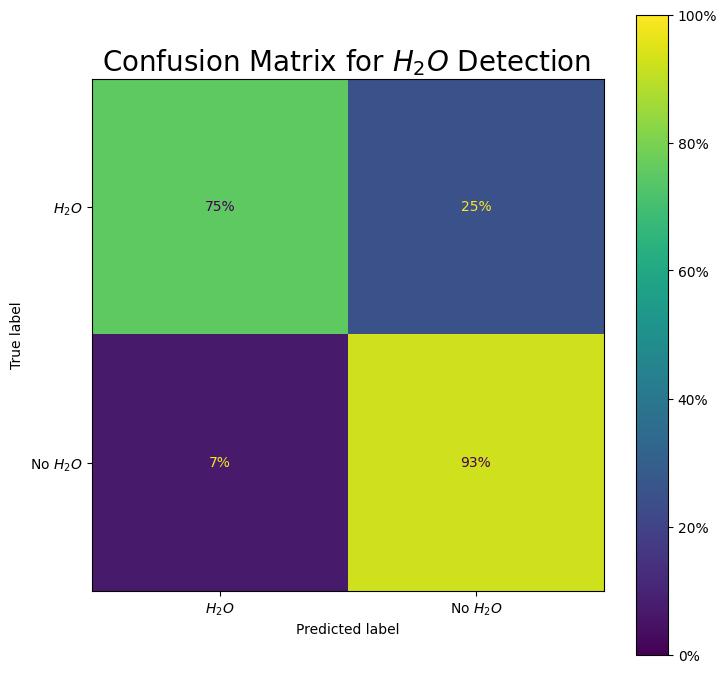

In [17]:
SNRall_probabilities = SNRall_rf.predict_proba(SNRall_X_test)[:, 1]

# Asignar etiquetas basadas en el umbral ajustado
threshold = 0.5
remove_warnings()
SNRall_y_pred = (SNRall_probabilities > threshold).astype(int)

# Asignar etiquetas y puntuaciones a las predicciones
SNRall_test["pred"] = SNRall_y_pred
SNRall_test["score"] = SNRall_probabilities

# Imprimir la matriz de confusión y el informe de clasificación
print(confusion_matrix(SNRall_y_test, SNRall_y_pred))
print(classification_report(SNRall_y_test, SNRall_y_pred))

plot_confusion_matrix(
    SNRall_y_test, SNRall_y_pred,
    labels=[1,0], display_labels=["$H_2O$", "No $H_2O$"],
    title="Confusion Matrix for $H_2O$ Detection "
)



### Validation


In [18]:
SNR = 1

SNR_val_CO2 = mrex.generate_df_SNR_noise(df=CO2_data,
                                        n_repeat=5000,
                                        SNR=SNR)
SNR_val_H2O = mrex.generate_df_SNR_noise(df=H2O_data,
                                         n_repeat=500,
                                         SNR=SNR)
SNR_val= pd.concat(
    [
        SNR_val_CO2,
        SNR_val_H2O
        ],
        ignore_index=True)


del (
    SNR_val_CO2,
    SNR_val_H2O
)

gc.collect()

SNR_val["label"] = SNR_val["label"].apply(string_to_list)
SNR_val["label"] = SNR_val["label"].apply(lambda x: x[2])

SNR_val_test = SNR_val


SNR_val_test.iloc[:,-n_points:]=normalize_min_max_by_row(SNR_val_test.iloc[:,-n_points:])


SNR_val_X_test = SNR_val_test.iloc[:, -n_points:]
SNR_val_y_test = SNR_val_test["label"].astype(int)

In [19]:
SNR_val_X_test

,5.297569,5.290111,5.28264,5.275158,5.267664,5.260158,5.252641,5.245111,5.237568,5.230015,...,0.764875,0.756764,0.748855,0.741148,0.733644,0.726317,0.71918,0.712225,0.705435,0.698805
0,0.652013,0.533702,0.518346,0.654157,0.495488,0.501793,0.196447,0.739595,0.499918,0.812146,...,0.313169,0.686892,0.399536,0.481471,0.649778,0.755932,0.398040,0.547377,0.470366,0.767597
1,0.515816,0.316209,0.304581,0.352290,0.362832,0.553674,0.564554,0.477897,0.273771,0.426830,...,0.402159,0.343474,0.497200,0.424707,0.560227,0.451299,0.536157,0.625881,0.354422,0.287294
2,0.123412,0.563936,0.305696,0.571977,0.197423,0.293728,0.583581,0.582033,0.513759,0.632076,...,0.492889,0.495079,0.438781,0.221364,0.586329,0.613216,0.657105,0.293226,0.545629,0.570474
3,0.773935,0.553028,0.717431,0.268427,0.390325,0.664469,0.627612,0.332804,0.718352,0.583579,...,0.516524,0.496456,0.371725,0.610404,0.438145,0.529801,0.169948,0.455878,0.477573,0.804366
4,0.280558,0.824320,0.932267,0.474116,0.624136,0.514156,0.336903,0.582481,0.283083,0.647583,...,0.683724,0.644178,0.459665,0.502318,0.489722,0.588216,0.659954,0.300941,0.549952,0.544979
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269995,0.357246,0.480051,0.429676,0.581819,0.520674,0.594648,0.277095,0.408250,0.552448,0.681197,...,0.389623,0.690424,0.332961,0.362036,0.544300,0.554131,0.328429,0.462550,0.567405,0.706293
269996,0.469883,0.616173,0.181655,0.579186,0.277502,0.381289,0.359058,0.247287,0.377709,0.506961,...,0.256767,0.339643,0.525464,0.418593,0.555173,0.506864,0.170941,0.766506,0.508282,0.196334
269997,0.595083,0.636349,0.566060,0.642649,0.584730,0.737704,0.489007,0.235175,0.562002,0.265937,...,0.486503,0.452801,0.267981,0.701574,0.422215,0.574607,0.152064,0.329430,0.311281,0.330422
269998,0.696071,0.573312,0.580591,0.661514,0.789392,0.310141,0.665982,0.679587,0.599714,0.603293,...,0.501460,0.507020,0.359265,0.455554,0.428269,0.318580,0.648668,0.427312,0.481979,0.600906


8438/8438 ━━━━━━━━━━━━━━━━━━━━ 8s 968us/step
[[90767 59233]
 [71105 48895]]
              precision    recall  f1-score   support

           0       0.56      0.61      0.58    150000
           1       0.45      0.41      0.43    120000

    accuracy                           0.52    270000
   macro avg       0.51      0.51      0.51    270000
weighted avg       0.51      0.52      0.51    270000



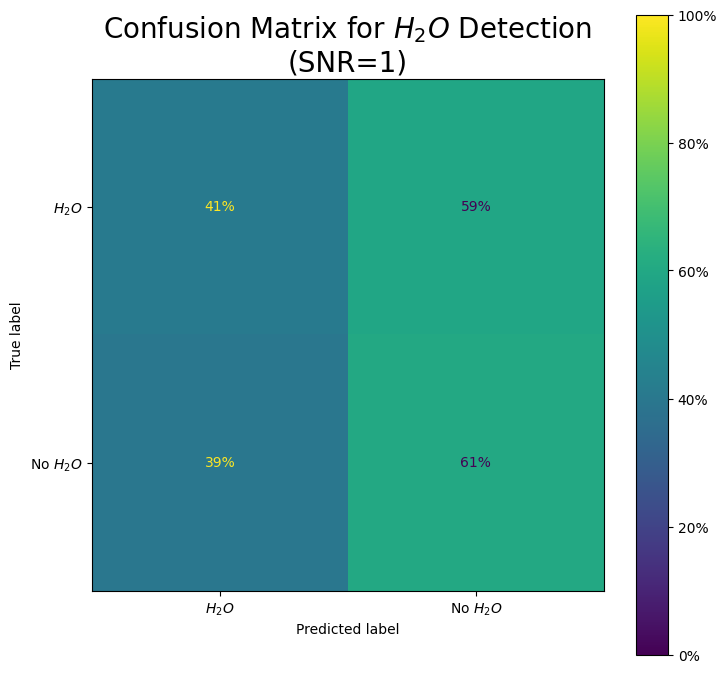

In [20]:
remove_warnings()
SNR_val_X_test = encoder.predict(SNR_val_X_test)
SNR_val_predictions = SNRall_rf.predict_proba(SNR_val_X_test)[:, 1]
threshold = 0.2
SNR_val_y_pred = (SNR_val_predictions > threshold).astype(int)
SNR_val_test["pred"] = SNR_val_y_pred
SNR_val_test["score"] = SNR_val_predictions


print(confusion_matrix(SNR_val_y_test, SNR_val_y_pred))
print(classification_report(SNR_val_y_test, SNR_val_y_pred))

plot_confusion_matrix(
    SNR_val_y_test, SNR_val_y_pred,
    labels=[1,0], display_labels=["$H_2O$", "No $H_2O$"],
    title=f"Confusion Matrix for $H_2O$ Detection\n(SNR={SNR})"
)

label
0    18750
1    15000
Name: count, dtype: int64
label
0    18750
1    15000
Name: count, dtype: int64
label
0    18750
1    15000
Name: count, dtype: int64
label
0    18750
1    15000
Name: count, dtype: int64
label
0    18750
1    15000
Name: count, dtype: int64
label
0    18750
1    15000
Name: count, dtype: int64
label
0    18750
1    15000
Name: count, dtype: int64
label
0    18750
1    15000
Name: count, dtype: int64
mix ratio:H2O=1e-08
[[11449  7301]
 [ 9043  5957]]
mean score of :H2O=1e-08 is 0.18857785979276853
mix ratio:H2O=1e-07
[[11326  7424]
 [ 9074  5926]]
mean score of :H2O=1e-07 is 0.18799201104156735
mix ratio:H2O=1e-06
[[11296  7454]
 [ 9034  5966]]
mean score of :H2O=1e-06 is 0.1911561181710633
mix ratio:H2O=9.999999999999999e-06
[[11239  7511]
 [ 9055  5945]]
mean score of :H2O=9.999999999999999e-06 is 0.19704352484259555
mix ratio:H2O=9.999999999999999e-05
[[11423  7327]
 [ 8889  6111]]
mean score of :H2O=9.999999999999999e-05 is 0.2108362454129401
mix ratio:H

Text(0.5, 1.0, 'Scores for $H_2O$ Detection\n(SNR=1)')

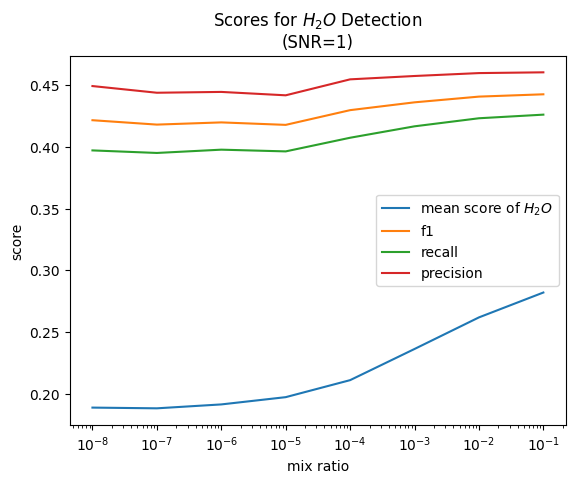

In [21]:
SNR_val_by_atmH2O=[[] for i in range(8)]

for i, j in enumerate(range(-8,-0)):
    SNR_val_by_atmH2O[i]=SNR_val_test[SNR_val_test["atm H2O"]==j]
    co2=int(len(SNR_val_test[SNR_val_test["label"]==0])/8)
    SNR_val_by_atmH2O[i]=pd.concat([SNR_val_by_atmH2O[i],
                                      SNR_val_test[SNR_val_test["label"]==0].sample(n=co2)])
    print(SNR_val_by_atmH2O[i]["label"].value_counts())
    
SNR_val_f1 = np.zeros(len(mix_ratios))
SNR_val_recall = np.zeros(len(mix_ratios))
SNR_val_precision = np.zeros(len(mix_ratios))
SNR_val_score = np.zeros(len(mix_ratios))

for j in range(len(mix_ratios)):
                
                SNR_val_f1[j] = f1_score(
                    SNR_val_by_atmH2O[j]["label"].astype(int),
                    SNR_val_by_atmH2O[j]["pred"].astype(int)
                    )
                
                SNR_val_recall[j] = recall_score(
                    SNR_val_by_atmH2O[j]["label"].astype(int),
                    SNR_val_by_atmH2O[j]["pred"].astype(int)
                    )
                
                SNR_val_precision[j]=precision_score(
                    SNR_val_by_atmH2O[j]["label"].astype(int),
                    SNR_val_by_atmH2O[j]["pred"].astype(int)
                    )
                
                print(f"mix ratio:H2O={mix_ratios[j]}")
                print(confusion_matrix(SNR_val_by_atmH2O[j]["label"].astype(int),
                                    SNR_val_by_atmH2O[j]["pred"].astype(int)))
                
                ## mean of probabilities of label 1
                print(f"mean score of :H2O={mix_ratios[j ]} is {SNR_val_by_atmH2O[j][SNR_val_by_atmH2O[j]['label']==1]['score'].mean()}")
                SNR_val_score[j] = SNR_val_by_atmH2O[j][
                    SNR_val_by_atmH2O[j]['label']==1
                    ]['score'].mean()

## plot scores
plt.figure()
plt.plot(mix_ratios,SNR_val_score,label="mean score of $H_2O$")
plt.plot(mix_ratios,SNR_val_f1,label="f1")
plt.plot(mix_ratios,SNR_val_recall,label="recall")
plt.plot(mix_ratios,SNR_val_precision,label="precision")

plt.xlabel("mix ratio")
plt.xscale("log")
plt.ylabel("score")

plt.legend()
plt.title(f"Scores for $H_2O$ Detection\n(SNR={SNR})")

## XGBoost


In [22]:
# %pip install xgboost


Training XGBoost model...


/mnt/Data/chikobara_github/Lumos/.venv311/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [18:53:26] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model training complete and saved.

--- Evaluating XGBoost Model ---
Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.82      0.95      0.88     29836
           1       0.92      0.74      0.82     23764

    accuracy                           0.85     53600
   macro avg       0.87      0.84      0.85     53600
weighted avg       0.86      0.85      0.85     53600



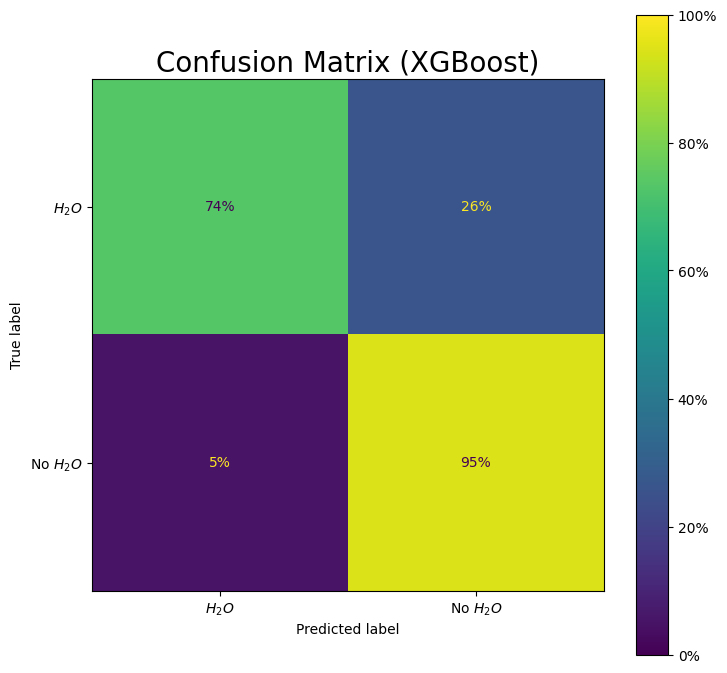

In [23]:
import xgboost as xgb # Added for XGBoost

# %%
print("\nTraining XGBoost model...")
SNRall_xgb = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=10, # XGBoost is often more sensitive to depth
    learning_rate=0.1,
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)
SNRall_xgb.fit(SNRall_X_train, SNRall_y_train)

joblib.dump(SNRall_xgb, "Models/H2O_xgb_S.joblib")
print("XGBoost model training complete and saved.")

# %%
print("\n--- Evaluating XGBoost Model ---")
SNRall_y_pred_xgb = SNRall_xgb.predict(SNRall_X_test)
print("Classification Report (XGBoost):")
print(classification_report(SNRall_y_test, SNRall_y_pred_xgb))
plot_confusion_matrix(
    SNRall_y_test, SNRall_y_pred_xgb,
    labels=[1, 0], display_labels=["$H_2O$", "No $H_2O$"],
    title="Confusion Matrix (XGBoost)"
)


## Model Comparison


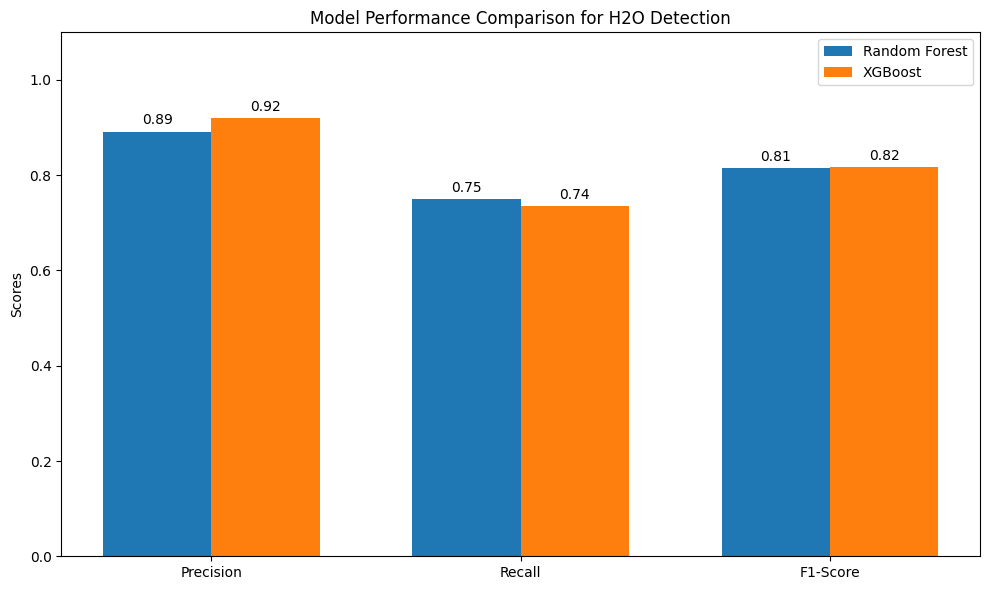

In [24]:
# Calculate metrics for both models
rf_precision = precision_score(SNRall_y_test, SNRall_y_pred)
rf_recall = recall_score(SNRall_y_test, SNRall_y_pred)
rf_f1 = f1_score(SNRall_y_test, SNRall_y_pred)

xgb_precision = precision_score(SNRall_y_test, SNRall_y_pred_xgb)
xgb_recall = recall_score(SNRall_y_test, SNRall_y_pred_xgb)
xgb_f1 = f1_score(SNRall_y_test, SNRall_y_pred_xgb)

# Create a comparison plot
labels = ['Precision', 'Recall', 'F1-Score']
rf_scores = [rf_precision, rf_recall, rf_f1]
xgb_scores = [xgb_precision, xgb_recall, xgb_f1]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, rf_scores, width, label='Random Forest')
rects2 = ax.bar(x + width/2, xgb_scores, width, label='XGBoost')

# Add some text for labels, title and axes ticks
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison for H2O Detection')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.set_ylim(0, 1.1)

fig.tight_layout()
plt.show()

# Implementing a 1D CNN Classifier


## Model Definition


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

def create_cnn_model(input_shape):
    """
    Creates and compiles a 1D CNN model for binary classification.

    Parameters:
        input_shape (tuple): The shape of the input data (e.g., (n_points, 1)).

    Returns:
        tensorflow.keras.Model: The compiled CNN model.
    """
    model = Sequential([
        # First convolutional layer
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # Second convolutional layer
        Conv1D(filters=64, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # Flatten the output to feed into the dense layer
        Flatten(),

        # Dense layer for classification
        Dense(100, activation='relu'),
        Dense(1, activation='sigmoid')  # Sigmoid for binary classification (H2O or No H2O)
    ])

    # Compile the model
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    return model

## Data preparation


In [26]:
# Assuming SNRall_X_train is already encoded by your Autoencoder
# Original shape might be (num_samples, n_features)

# Reshape data for CNN input
# Add an extra dimension for the 'channels'
SNRall_X_train_cnn = np.expand_dims(SNRall_X_train, axis=-1)
SNRall_X_test_cnn = np.expand_dims(SNRall_X_test, axis=-1)

# Check the new shape
print(f"New training data shape for CNN: {SNRall_X_train_cnn.shape}")

# Define the input shape for the model
input_shape = (SNRall_X_train_cnn.shape[1], 1)


New training data shape for CNN: (214400, 385, 1)


## Training and Evaluation


\n--- Training CNN Model ---


/mnt/Data/chikobara_github/Lumos/.venv311/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 383, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 191, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 191, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 189, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 94, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 94, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6016)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       601,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 608,137 (2.32 MB)

...

Epoch 1/20


I0000 00:00:1755100439.918868  251308 service.cc:152] XLA service 0x7f0d80026360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755100439.919583  251308 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-08-13 18:53:59.990951: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1755100440.254167  251308 cuda_dnn.cc:529] Loaded cuDNN version 90300


  62/2680 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6867 - loss: 0.5659

I0000 00:00:1755100442.466828  251308 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2680/2680 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.7584 - loss: 0.4671 - val_accuracy: 0.7719 - val_loss: 0.4504
Epoch 2/20
2680/2680 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7722 - loss: 0.4483 - val_accuracy: 0.7754 - val_loss: 0.4468
Epoch 3/20
2680/2680 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7720 - loss: 0.4500 - val_accuracy: 0.7758 - val_loss: 0.4445
Epoch 4/20
2680/2680 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7753 - loss: 0.4446 - val_accuracy: 0.7767 - val_loss: 0.4442
Epoch 5/20
2680/2680 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7756 - loss: 0.4434 - val_accuracy: 0.7767 - val_loss: 0.4442
Epoch 6/20
2680/2680 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7768 - loss: 0.4420 - val_accuracy: 0.7768 - val_loss: 0.4459
Epoch 7/20
2680/2680 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7772 - loss: 0.4435 - val_accuracy: 0.7769 - val_loss: 0.4429
Epoch 8/20
2680/2680 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7772 - loss: 0.4418 - val_accura

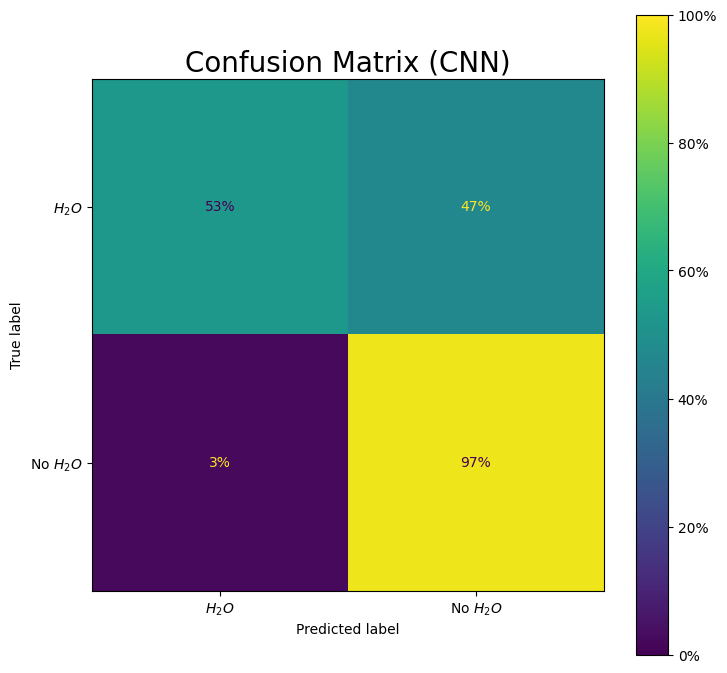

In [27]:

import joblib
from sklearn.metrics import classification_report, confusion_matrix

print("\\n--- Training CNN Model ---")

# Create the CNN model
cnn_model = create_cnn_model(input_shape)
cnn_model.summary()

# Train the model
history = cnn_model.fit(SNRall_X_train_cnn, SNRall_y_train,
                        epochs=20,  # You can adjust the number of epochs
                        batch_size=64,
                        validation_split=0.2, # Use part of training data for validation
                        verbose=1)

# Save the trained model
cnn_model.save("Models/H2O_cnn_S.keras")
print("CNN model training complete and saved.")

# --- Evaluating CNN Model ---
print("\\n--- Evaluating CNN Model ---")
# Predict probabilities on the test set
cnn_probabilities = cnn_model.predict(SNRall_X_test_cnn).flatten()

# Convert probabilities to binary predictions using a 0.5 threshold
cnn_y_pred = (cnn_probabilities > 0.5).astype(int)

print("\\nClassification Report (CNN):")
print(classification_report(SNRall_y_test, cnn_y_pred))

plot_confusion_matrix(
    SNRall_y_test, cnn_y_pred,
    labels=[1, 0], display_labels=["$H_2O$", "No $H_2O$"],
    title="Confusion Matrix (CNN)"
)

# Hybrid Model Approach (Advanced Option) 🚀


In [28]:
from tensorflow.keras.models import Model

# Use the trained cnn_model from before
# Create a new model that outputs the result of the second-to-last layer (the dense features)
feature_extractor = Model(inputs=cnn_model.inputs, outputs=cnn_model.layers[-2].output)



## Extract Features:


In [29]:

# Use the feature extractor to transform your data
X_train_features = feature_extractor.predict(SNRall_X_train_cnn)
X_test_features = feature_extractor.predict(SNRall_X_test_cnn)


6700/6700 ━━━━━━━━━━━━━━━━━━━━ 5s 739us/step
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 1s 876us/step


## Train XGBoost on New Features:


/mnt/Data/chikobara_github/Lumos/.venv311/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [18:56:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.81      0.95      0.88     29836
           1       0.92      0.72      0.81     23764

    accuracy                           0.85     53600
   macro avg       0.87      0.84      0.84     53600
weighted avg       0.86      0.85      0.85     53600

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.82      0.95      0.88     29836
           1       0.92      0.74      0.82     23764

    accuracy                           0.85     53600
   macro avg       0.87      0.84      0.85     53600
weighted avg       0.86      0.85      0.85     53600



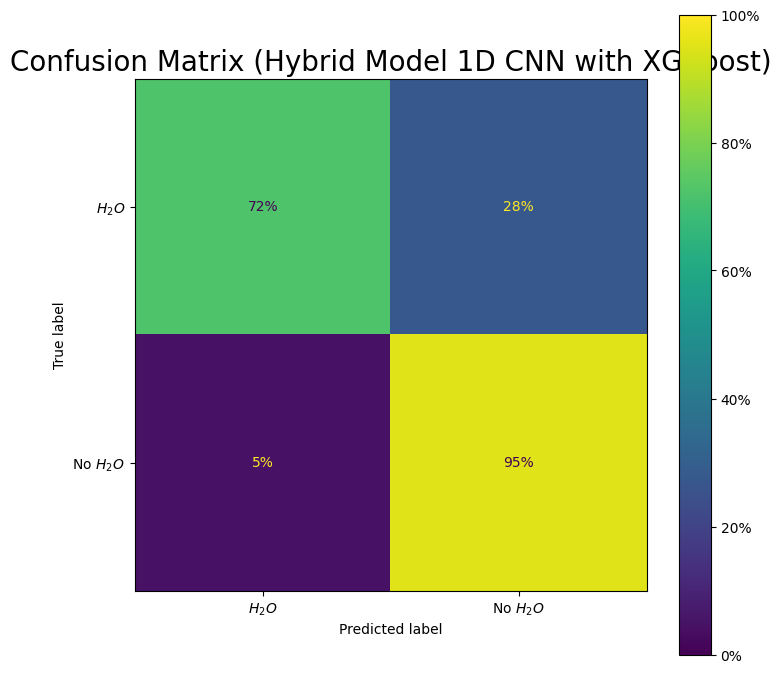

In [30]:


# Now, train your XGBoost model on these new, high-level features
xgb_hybrid = xgb.XGBClassifier(    
    n_estimators=100,
    max_depth=10, # XGBoost is often more sensitive to depth
    learning_rate=0.1,
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
) # Your XGBoost parameters
xgb_hybrid.fit(X_train_features, SNRall_y_train)

# Evaluate
y_pred_hybrid = xgb_hybrid.predict(X_test_features)
print(classification_report(SNRall_y_test, y_pred_hybrid))


print("Classification Report (XGBoost):")
print(classification_report(SNRall_y_test, SNRall_y_pred_xgb))
plot_confusion_matrix(
    SNRall_y_test, y_pred_hybrid,
    labels=[1, 0], display_labels=["$H_2O$", "No $H_2O$"],
    title="Confusion Matrix (Hybrid Model 1D CNN with XGBoost)"
)